# Transformer VAE Training — H1N1 & H3N2

Trains a Transformer-based VAE on **both** influenza subtypes with identical
hyperparameters (latent dim, KL annealing, learning rate) for a fair architecture
comparison against the Conv1D VAE in the final report.

The encoder uses sinusoidal positional encoding + multi-head self-attention, then
mean-pools over positions to produce μ and log σ². The decoder broadcasts z back
to all positions and runs self-attention to reconstruct the one-hot sequence.

In [ ]:
import os
if not os.path.exists('models'):
    !git clone https://github.com/sidms24/AML.git
    os.chdir('AML')
!pip install -q -r requirements.txt

Cloning into 'AML'...
remote: Enumerating objects: 601, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 601 (delta 90), reused 4 (delta 4), pack-reused 454 (from 2)
Receiving objects: 100% (601/601), 23.86 MiB | 12.28 MiB/s, done.
Resolving deltas: 100% (360/360), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 12.8 MB/s eta 0:00:00


## Shared Hyperparameters

Latent dim, batch size, learning rate, KL annealing, and early stopping are
**identical** to the Conv1d VAE notebook for a fair comparison.
The transformer-specific params (`d_model`, `nhead`, `num_layers`,
`dim_feedforward`) are additional architecture knobs.

In [ ]:
import tqdm
import tqdm.auto
tqdm.auto.tqdm = tqdm.tqdm
import torch
from models.transformer_vae import TransformerVAE
from utils.dataloader import load_data
from utils.encoders import dna_one_hot
from utils.loss import VAE_Loss
from utils.train import VAE_train
from utils.plot_funcs import plot_training_curves
from utils.sirc_helpers import load_tvae_from_hf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

best_config = {'latent_dim': 128, 'beta': 0.028630640852697415, 'd_model': 128,
               'num_layers': 3, 'num_memory_tokens': 8,
               'lr': 0.0002532556033608517, 'dropout': 0.1}

LATENT_DIM = best_config['latent_dim']
BATCH_SIZE = 512
EPOCHS = 200
LR = best_config['lr']
BETA =  best_config['beta']
ANNEAL_EPOCHS = 10
PATIENCE = 10

D_MODEL = best_config['d_model']
NHEAD = 4
NUM_LAYERS= best_config['num_layers']
DIM_FEEDFORWARD   = 256
DROPOUT  = best_config['dropout']
NUM_MEMORY_TOKENS = best_config['num_memory_tokens']
SAVE_EVERY = 50


TRAIN = False

In [ ]:
# reproducibility — pin all sources of randomness so training is deterministic
import numpy as np
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True

# H1N1

In [ ]:
h1n1_data = load_data(subtype='H1N1_global', encoder=dna_one_hot, batch_size=BATCH_SIZE)
h1n1_train, h1n1_test = h1n1_data()

# grab one batch to auto-detect input shape
sample_x, _ = next(iter(h1n1_train))
INPUT_DIM = sample_x.shape[1]   # 5 channels (one-hot: A, C, G, T, gap)
SEQ_LENGTH = sample_x.shape[2]
print(f'H1N1 — input_dim={INPUT_DIM}, seq_length={SEQ_LENGTH}, batches={len(h1n1_train)}')

Map (num_proc=4): 100%|██████████| 6245/6245 [00:01<00:00, 4349.21 examples/s]


H1N1 — input_dim=5, seq_length=1759, batches=49


In [ ]:
if TRAIN:

  tvae_h1n1 = TransformerVAE(
      input_dim=INPUT_DIM, d_model=D_MODEL, latent_dim=LATENT_DIM,
      seq_length=SEQ_LENGTH, nhead=NHEAD, num_layers=NUM_LAYERS,
      dim_feedforward=DIM_FEEDFORWARD, dropout=DROPOUT
  ).to(device)

  criterion_h1n1 = VAE_Loss(beta=BETA)
  optimiser_h1n1 = torch.optim.AdamW(tvae_h1n1.parameters(), lr=LR, weight_decay=1e-2)

  # VAE_train handles KL annealing and early stopping internally —
  # works with TransformerVAE because forward() returns the same (x_hat, mu, logvar) tuple
  tvae_h1n1, history_h1n1 = VAE_train(
      tvae_h1n1, h1n1_train, h1n1_test,
      criterion_h1n1, optimiser_h1n1, device,
      epochs=EPOCHS, patience=PATIENCE, anneal_epochs=ANNEAL_EPOCHS, save_every=SAVE_EVERY
  )
else:
  tvae_h1n1 ,_, history_h1n1 = load_tvae_from_hf('tvae_h1n1_weights.pt', dev=device)


  Config: {'input_dim': 5, 'd_model': 128, 'latent_dim': 128, 'seq_length': 1759, 'nhead': 4, 'num_layers': 3, 'dim_feedforward': 256, 'dropout': 0.1, 'num_memory_tokens': 8}


In [ ]:
plot_training_curves(history_h1n1)

In [13]:
# save config alongside weights so we can reconstruct the model without guessing dims
torch.save({
    'model_state_dict': tvae_h1n1.state_dict(),
    'config': {'input_dim': INPUT_DIM, 'd_model': D_MODEL,
               'latent_dim': LATENT_DIM, 'seq_length': SEQ_LENGTH,
               'nhead': NHEAD, 'num_layers': NUM_LAYERS,
               'dim_feedforward': DIM_FEEDFORWARD, 'dropout': DROPOUT,
               'num_memory_tokens': NUM_MEMORY_TOKENS},
    'history': history_h1n1,
    'best_config': best_config,
}, 'tvae_h1n1_weights.pt')

In [ ]:
if TRAIN:
  del criterion_h1n1, optimiser_h1n1
  torch.cuda.empty_cache()
  import gc; gc.collect()
  print(f'GPU memory after cleanup: {torch.cuda.memory_allocated()/1e6:.0f} MB')

# H3N2

In [ ]:
# same pipeline as H1N1 — H3N2 seqs may differ in length
h3n2_data = load_data(subtype='H3N2_global', encoder=dna_one_hot, batch_size=BATCH_SIZE)
h3n2_train, h3n2_test = h3n2_data()

sample_x2, _ = next(iter(h3n2_train))
INPUT_DIM_H3 = sample_x2.shape[1]
SEQ_LENGTH_H3 = sample_x2.shape[2]
print(f'H3N2 — input_dim={INPUT_DIM_H3}, seq_length={SEQ_LENGTH_H3}, batches={len(h3n2_train)}')

Map (num_proc=4): 100%|██████████| 9332/9332 [00:02<00:00, 4659.74 examples/s]


H3N2 — input_dim=5, seq_length=1854, batches=73


In [8]:
# fresh model — we don't share weights between subtypes

if TRAIN:
  tvae_h3n2 = TransformerVAE(
      input_dim=INPUT_DIM_H3, d_model=D_MODEL, latent_dim=LATENT_DIM,
      seq_length=SEQ_LENGTH_H3, nhead=NHEAD, num_layers=NUM_LAYERS,
      dim_feedforward=DIM_FEEDFORWARD, dropout=DROPOUT
  ).to(device)

  criterion_h3n2 = VAE_Loss(beta=BETA)
  optimiser_h3n2 = torch.optim.AdamW(tvae_h3n2.parameters(), lr=LR, weight_decay=1e-2)

  tvae_h3n2, history_h3n2 = VAE_train(
      tvae_h3n2, h3n2_train, h3n2_test,
      criterion_h3n2, optimiser_h3n2, device,
      epochs=EPOCHS, patience=PATIENCE, anneal_epochs=ANNEAL_EPOCHS
  )
else:
  tvae_h3n2 ,_, history_h3n2 = load_tvae_from_hf('tvae_h3n2_weights.pt', dev=device)

Training:   5%|▌         | 10/200 [08:15<2:03:47, 39.09s/epoch, avg loss=81.6514]

  Checkpoint saved at epoch 10 -> checkpoint.pt


Training:  10%|█         | 20/200 [14:31<1:52:59, 37.66s/epoch, avg loss=45.4298]

  Checkpoint saved at epoch 20 -> checkpoint.pt


Training:  15%|█▌        | 30/200 [20:47<1:46:35, 37.62s/epoch, avg loss=36.1640]

...

  Checkpoint saved at epoch 180 -> checkpoint.pt


Training:  95%|█████████▌| 190/200 [2:01:14<06:16, 37.69s/epoch, avg loss=24.0360]

  Checkpoint saved at epoch 190 -> checkpoint.pt


Training: 100%|██████████| 200/200 [2:07:30<00:00, 38.25s/epoch, avg loss=23.6270]

  Checkpoint saved at epoch 200 -> checkpoint.pt


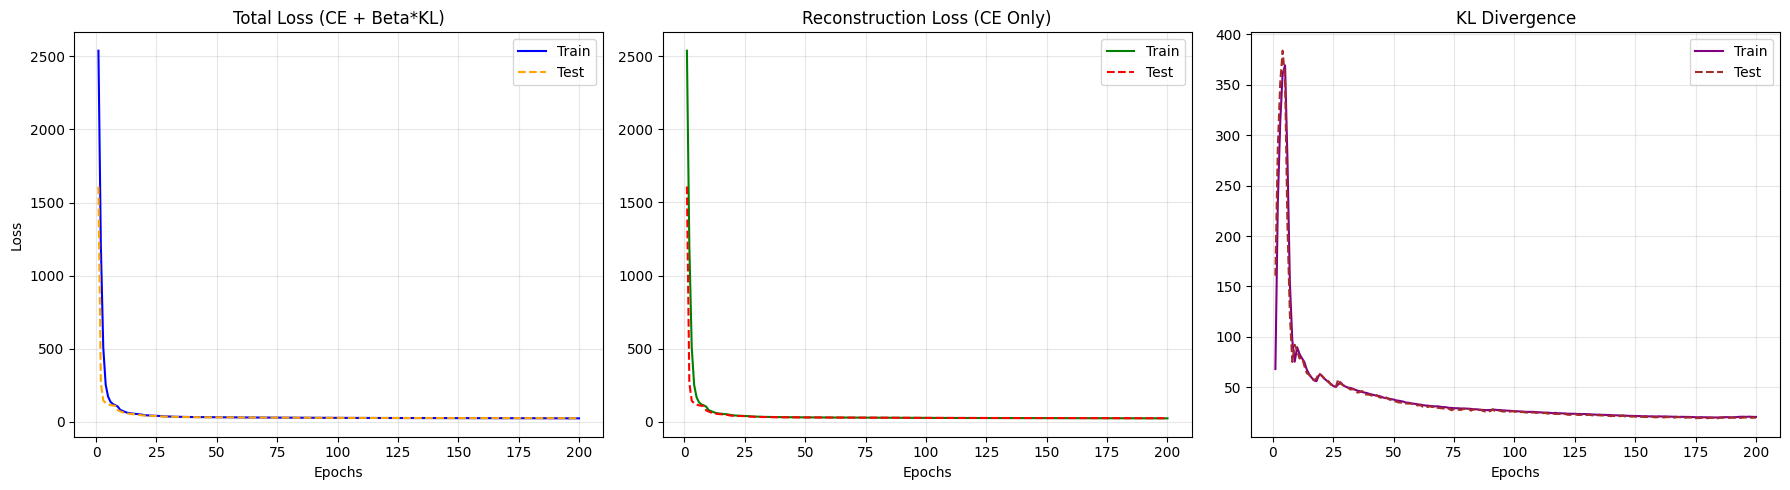

In [9]:
plot_training_curves(history_h3n2)

In [10]:
torch.save({
    'model_state_dict': tvae_h3n2.state_dict(),
    'config': {'input_dim': INPUT_DIM_H3, 'd_model': D_MODEL,
               'latent_dim': LATENT_DIM, 'seq_length': SEQ_LENGTH_H3,
               'nhead': NHEAD, 'num_layers': NUM_LAYERS,
               'dim_feedforward': DIM_FEEDFORWARD, 'dropout': DROPOUT,
               'num_memory_tokens': NUM_MEMORY_TOKENS},
    'history': history_h3n2,
    'best_config': best_config,
}, 'tvae_h3n2_weights.pt')

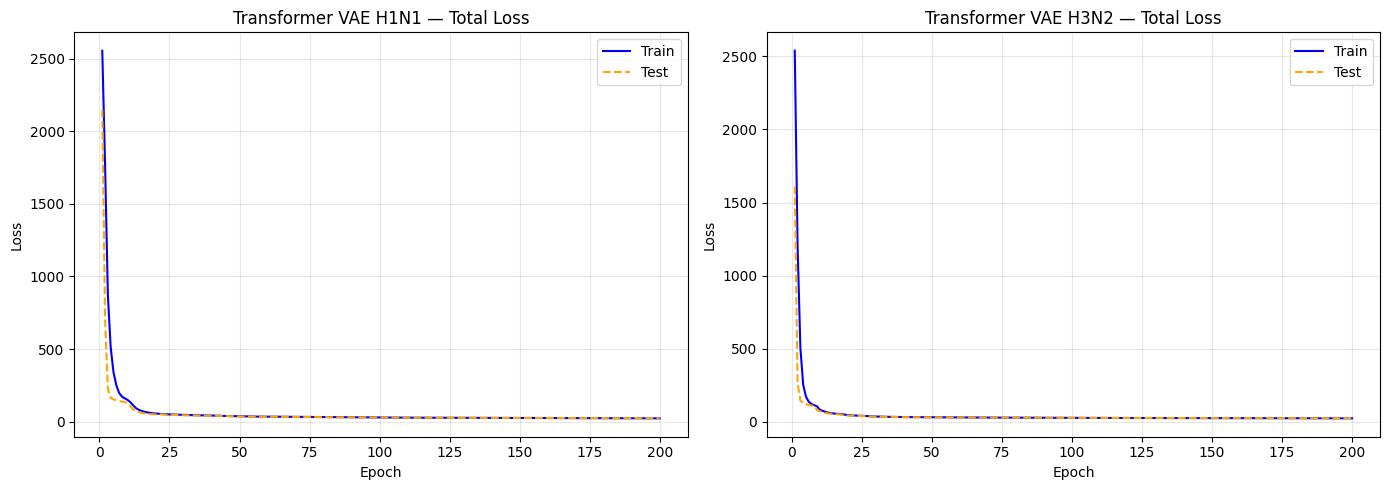

H1N1 final test loss: 23.96
H3N2 final test loss: 24.31


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, name in [(axes[0], history_h1n1, 'H1N1'), (axes[1], history_h3n2, 'H3N2')]:
    ep = range(1, len(hist['train_tloss']) + 1)
    ax.plot(ep, hist['train_tloss'], label='Train', color='blue')
    ax.plot(ep, hist['test_tloss'], label='Test', color='orange', linestyle='--')
    ax.set_title(f'Transformer VAE {name} — Total Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'H1N1 final test loss: {history_h1n1["test_tloss"][-1]:.2f}')
print(f'H3N2 final test loss: {history_h3n2["test_tloss"][-1]:.2f}')

In [ ]:
from datasets import Dataset, DatasetDict
from huggingface_hub import login, upload_file
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

models = ['tvae_h3n2_weights.pt', 'tvae_h1n1_weights.pt']
for model in models:
  upload_file(
      path_or_fileobj=model,
      repo_id='sidms/AML',
      path_in_repo= f'weights/{model}',
      repo_type= 'dataset',
      token=hf_token
  )